<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_2_2a_SigvsRef_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iris-hep/nsbi-lhc-toolkit/blob/main/workshops/ml4hep_tifr/Exercise_2_2a_SigvsRef_training.ipynb)

Density Ratio Training - Signal vs Reference
---

In the 2a and 2b notebooks we will setup the neural networks that train unbiased and low-variance density ratios to be then used for building SBI model, which can be written as:

$$ \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = \prod_{x_e\in \{x\}} \frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \left[\mu \cdot \lambda_\mathrm{sig} \cdot \frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)} + \lambda_\mathrm{bkg} \cdot \frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}\right]$$

which we will then used to build the test statisti in the `3_parameter_fitting.ipynb` notebook. The ratios to estimate using NN are now:

$$ \hat{r}_\mathrm{sig}(x) = \frac{p_\mathrm{sig}(x)}{p_\mathrm{ref}(x)}, \qquad  \hat{r}_\mathrm{bkg}(x) = \frac{p_\mathrm{bkg}(x)}{p_\mathrm{ref}(x)} $$


In this notebook we will use the `nsbi-common-utils` to estimate $\hat{r}_\mathrm{sig}(x)$ via neural networks. Because the underlying densities are Gaussian *mixtures* with overlapping support, the classifier score stays bounded away from 0 and 1 and the resulting ratio is numerically stable.

In [1]:
## ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 1_000_000, 1_000_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = True                    # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime onnxscript iminuit mplhep

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if not os.path.exists("dataframes/signal.parquet"):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.7/93.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 154.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 151.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.5 MB/s eta 0:00:00
Working dir: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/worksh

In [2]:
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

Insert the path to the downloaded dataset (see README for download link)

In [3]:
BASE_PATH = "./dataframes/"

Load the signal and background datasets

In [4]:
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

### Train / inference split

The density ratios must be **trained** and the likelihood **evaluated** on *different* events, otherwise the parameter fit inherits the classifier's overfitting. We split each sample with a fixed seed: the training notebooks (2a, 2b) keep the *training* half and the fitting notebook (3) keeps the *inference* half.

`SPLIT_SEED` and `TRAIN_FRACTION` **must be identical across all three notebooks** — the shared seed is what guarantees the two halves are disjoint. Change `TRAIN_FRACTION` (or pass `n_train=<int>` to `split_train_inference`) to adjust how many events go to training vs. inference.

In [5]:
from utils import split_train_inference

SPLIT_SEED = 0
TRAIN_FRACTION = 0.5  # fraction of each sample used for TRAINING

signal, _ = split_train_inference(signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)
background, _ = split_train_inference(background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)

print(f"Training on {len(signal):,} signal + {len(background):,} background events")

Training on 500,000 signal + 500,000 background events


We will use the full high-dimensional feature space to train the density ratios

In [6]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

The numerator and denominator hypothesis refer to the signal and reference hypothesis respectively for this notebook. Remember, the objective is to train a model that estimates

$$ \hat{r}_\mathrm{sig}(x) = \frac{p_\mathrm{sig}(x)}{p_\mathrm{ref}(x)} $$

We will choose the reference hypothesis to be a combination of the signal and background so there are no phase space regions with $p_\mathrm{ref}(x) \approx 0$ during training.

The choice of reference is one of the difficult and less well-defined parts of the SBI approach -  it has significant impact on numerical stability.

In [7]:
numerator_hypothesis = signal.astype('float32').copy()
denominator_hypothesis = pd.concat([background, signal], ignore_index=True).astype('float32').copy()

Build a combined training dataset consisting of events from numerator and denominator hypothesis. By using `weights_normed` the binary cross-entropy loss function sees both classes represented equally, allowing us to use the likelihood-ratio trick for density ratio estimation. `train_labels` correspond to the truth labels that go into the binary cross-entropy loss function.

In [8]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

Select a subset of events to train on

In [9]:
N_TRAIN = 1_500_000  # None = use all events

training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)
training_dataframe = training_dataframe.sample(frac=1, random_state=42, ignore_index=True)

if N_TRAIN is not None:
    training_dataframe = training_dataframe.head(N_TRAIN).reset_index(drop=True)
    # Re-normalize per-class weights so each class still sums to 1 after subsetting
    for label_val in [0.0, 1.0]:
        mask = training_dataframe["train_labels"] == label_val
        training_dataframe.loc[mask, "weights_normed"] = (
            training_dataframe.loc[mask, "weight"]
            / training_dataframe.loc[mask, "weight"].sum()
        )

### Neural Network Training

In [10]:
ensemble_size = 1

In [11]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = [None for i in range(ensemble_size)]

for ens_index in range(ensemble_size):
    trainer[ens_index] = density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"],
        training_labels=training_dataframe["train_labels"],
        features=training_features,
        features_scaling=training_features,
        sample_name=["signal", "reference"],
        output_name="",
        path_to_figures="plots_SigvsRef/",
        path_to_models="models_SigvsRef/",
    )

### HyperParameters

The default parameters build a wide multi-layer perceptron (MLP) that has been optimized for estimating well-calibrated and unbiased density ratios in most cases.

Exercise: try changing hyperparameters like hidden_layers or neurons or batch_size and see what results you get - both in terms of diagnostics and final parameter fits.

In [12]:
for ens_index in range(ensemble_size):

    trainer[ens_index].train(
        hidden_layers=5,
        neurons=1024,
        number_of_epochs=50,
        batch_size=1024,
        learning_rate=1e-3,
        scalerType="MinMax",
        ensemble_index=ens_index,
        verbose=1,
        holdout_split=0.25, # validation
        validation_split=0.2,
        callback_patience=10,
        num_workers=4,
        load_trained_models=False,
        calibration=False,
        type_of_calibration = "histogram",
        recalibrate_output=True,
        num_bins_cal = 50
    )

2026-07-08 00:50:36 | INFO | Training Logs | Sum of weights of class 0: 0.7495186924934387
INFO:Training Logs:Sum of weights of class 0: 0.7495186924934387
2026-07-08 00:50:36 | INFO | Training Logs | Sum of weights of class 1: 0.75
INFO:Training Logs:Sum of weights of class 1: 0.75
2026-07-08 00:50:36 | INFO | Training Logs | Using swish activation function
INFO:Training Logs:Using swish activation function
2026-07-08 00:50:36 | INFO | Training Logs | Setting log loss to False
INFO:Training Logs:Setting log loss to False
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-pa

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  4.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 4.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.2 M                                                                                                
Total estimated model params size (MB): 16.822                                                                     
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch    0 | lr = 1.000e-03 | val_loss = 0.693574 | 
Epoch    0 | lr = 1.000e-03 | val_loss = 0.514024 | 
Epoch    1 | lr = 1.000e-03 | train_loss = 0.529887 | val_loss = 0.518476 | 
Epoch    2 | lr = 1.000e-03 | train_loss = 0.513724 | val_loss = 0.514046 | 
Epoch    3 | lr = 1.000e-03 | train_loss = 0.512550 | val_loss = 0.513491 | 
Epoch    4 | lr = 1.000e-03 | train_loss = 0.511903 | val_loss = 0.512664 | 
Epoch    5 | lr = 1.000e-03 | train_loss = 0.511438 | val_loss = 0.512278 | 
Epoch    6 | lr = 1.000e-03 | train_loss = 0.511204 | val_loss = 0.693147 | 
Epoch    7 | lr = 1.000e-03 | train_loss = 0.597098 | val_loss = 0.693147 | 
Epoch    8 | lr = 1.000e-03 | train_loss = 0.693152 | val_loss = 0.693154 | 
Epoch    9 | lr = 1.000e-05 | train_loss = 0.693154 | val_loss = 0.693147 | 
Epoch   10 | lr = 1.000e-05 | train_loss = 0.693154 | val_loss = 0.693146 | 
Epoch   11 | lr = 1.000e-05 | train_loss = 0.693148 | val_loss = 0.693146 | 
Epoch   12 | lr = 1.000e-05 | train_loss = 0.69

...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-07-08 00:57:37 | INFO | Training Logs | reference training data has min ratio 0.011506926268339157
INFO:Training Logs:reference training data has min ratio 0.011506926268339157
2026-07-08 00:57:37 | INFO | Training Logs | reference training data has max ratio 89.01763153076172
INFO:Training Logs:reference training data has max ratio 89.01763153076172
2026-07-08 00:57:37 | INFO | Training Logs | signal training data has min ratio 0.012328533455

<Figure size 800x600 with 0 Axes>

Diagnostic Checks
===

While traditionally, a NN observable is judged on the basis of its accuracy - for NSBI we are interested in the quality of the density ratios more than the discrimination power. The latter comes from the perfect modelling of the multi-dimensional likelihood ratios.

To ensure correct modelling, we run two main checks on the training:

- **Calibration closure test**

  The NNs are trained using the binary cross-entropy loss, which under ideal conditions leads to the NN converging to the score function:

  $$\hat{s}_\text{pred} = \frac{p_\text{s}(x)}{p_\text{ref}(x)+p_\text{s}(x)}$$

  that can be converted into the probability ratio we desire (likelihood ratio trick):

  $$\frac{p_\text{s}(x)}{p_\text{ref}(x)} = \frac{\hat{s}_\text{pred}(x)}{1-\hat{s}_\text{pred}(x)}$$

  For the NNs to be well-calibrated, we use the Monte Carlo samples to verify the equality:


  $$\left[\frac{p_s(x)}{p_s(x)+p_{ref}(x)}\right]_\text{NN} \sim \left[\frac{\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}}{\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}+\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}}\right]_\text{MC}$$

  where we bin the events from $p_c$ and $p_\text{ref}$ MC samples, denoted by $\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}$ and $\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}$ respectively where $I(x|\hat{s}_\text{pred})$ returns the index of the $\hat{s}_\text{pred}$ bin in which an event $x$ falls.



In [13]:
ens_index_to_plot = 0

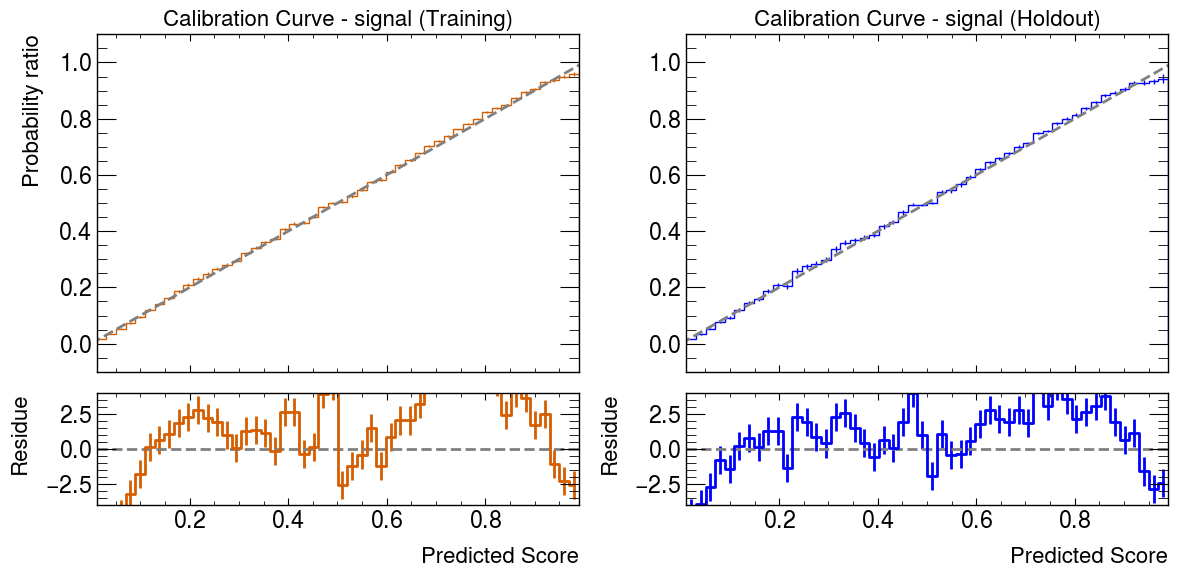

<Figure size 800x600 with 0 Axes>

In [14]:
trainer[ens_index_to_plot].make_calib_plots(observable='score', nbins=50, ensemble_index=0)

## Density ratio reweighting closure tests
  
Despite having a well-calibrated output and thus a robust probabilistic interpretation, the trained density ratios might not capture the full multi-dimensional event information $x$.

The next diagnostic involves verifying the following equality using 1D projections of $x$:

$$\frac{p_s(x)}{p_{ref}(x)} \times p_{ref}(x) \sim p_s(x)$$

We can do this one-by-one for all the observables used to model the density ratios, and also possibly the observables not used directly in the training but can still be well-estimated due to the NN learning the right physics.

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:318: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


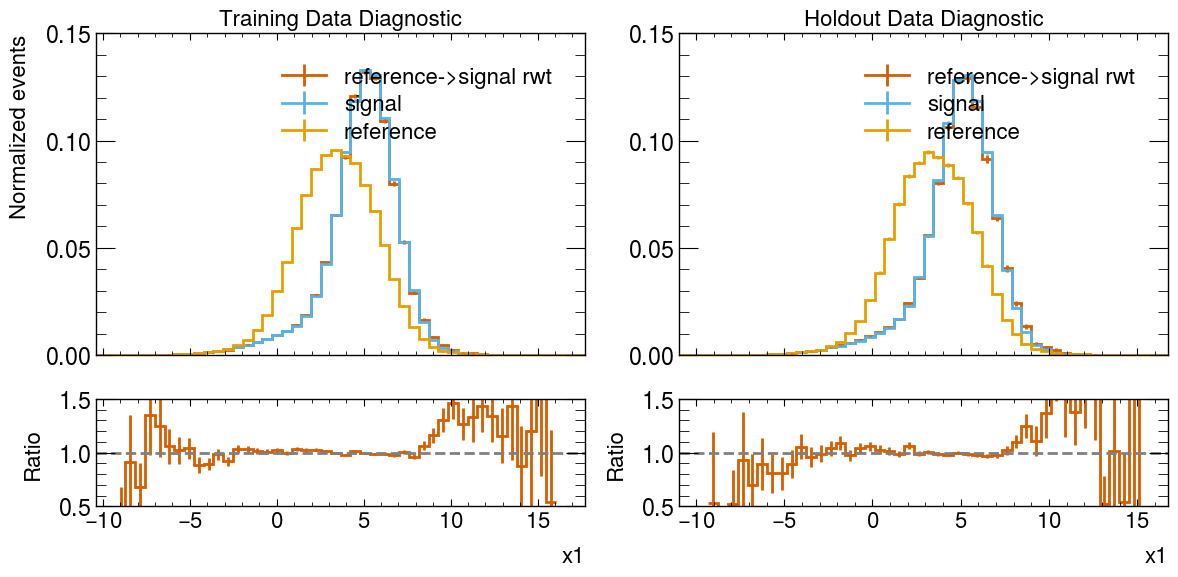

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/p

<Figure size 800x600 with 0 Axes>

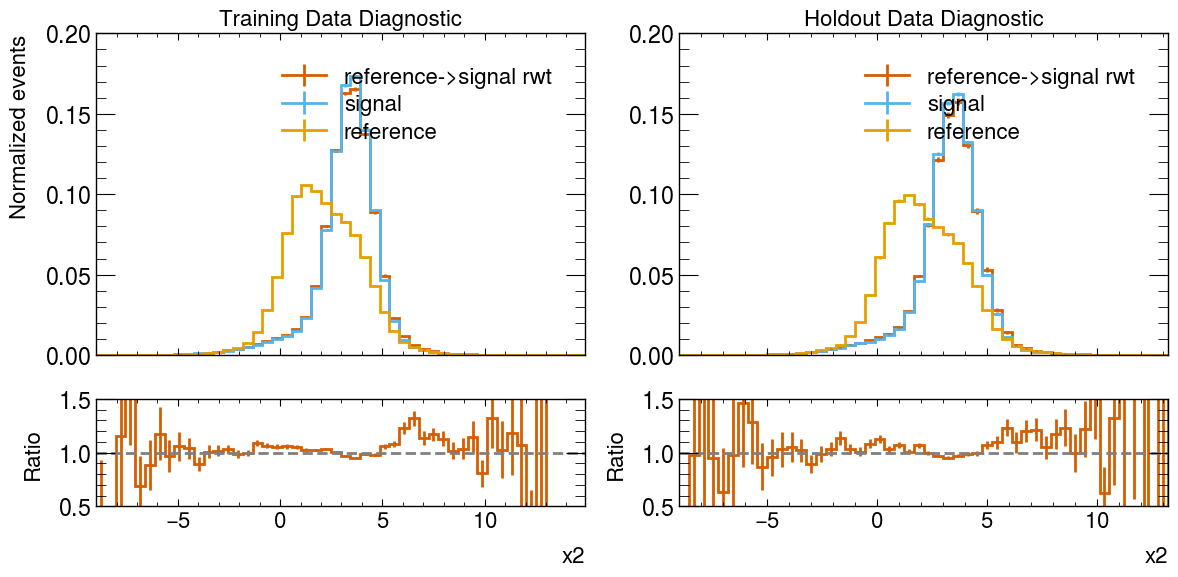

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:318: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

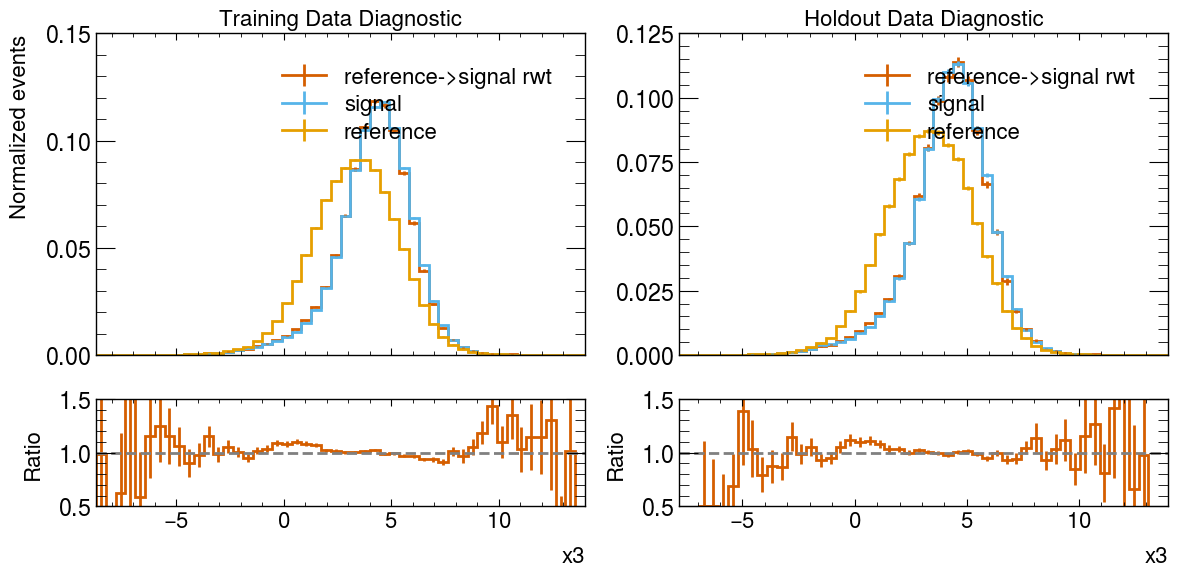

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:318: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

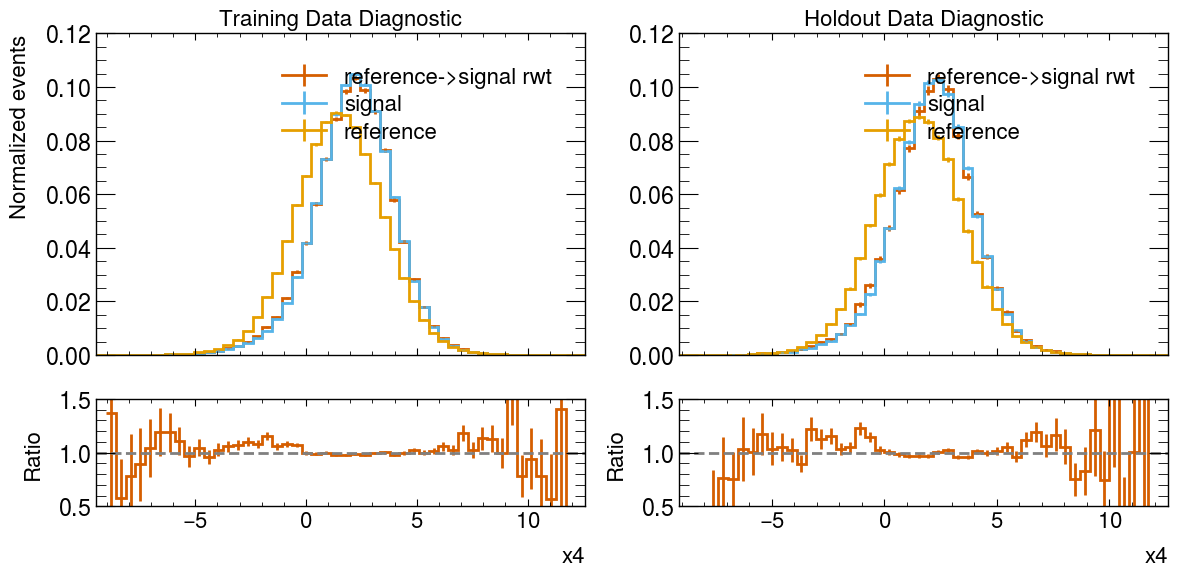

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:294: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:295: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:317: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/

<Figure size 800x600 with 0 Axes>

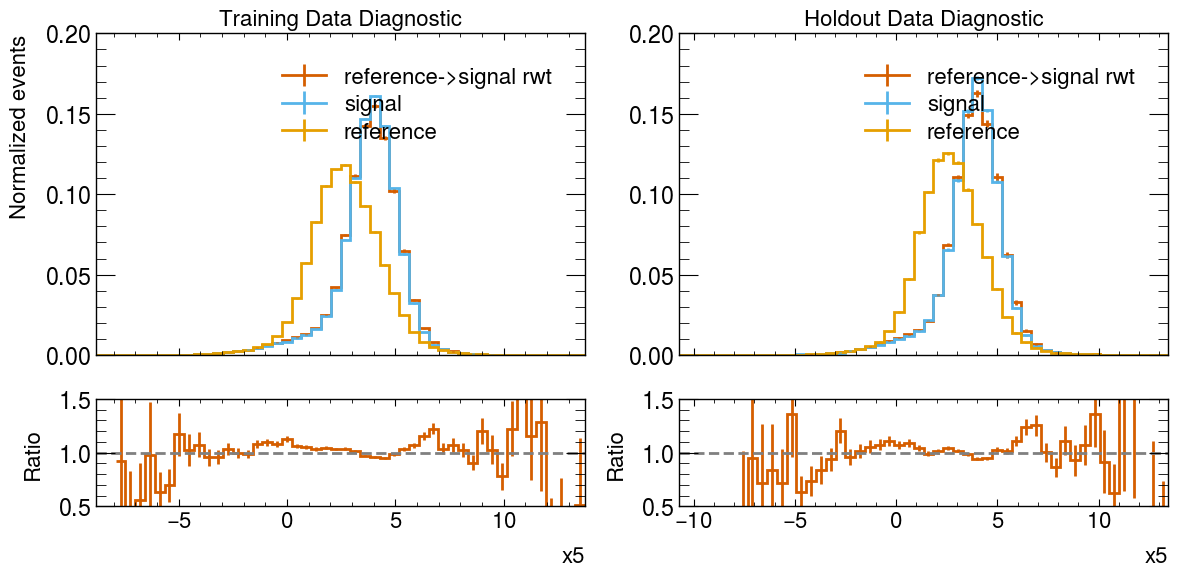

<Figure size 800x600 with 0 Axes>

In [15]:
trainer[ens_index_to_plot].make_reweighted_plots(training_features, "linear", 50)